In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score
import pickle

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow Version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available:", len(gpus))
if gpus:
    print("Using GPU:", gpus[0].name)
else:
    print("Using CPU for training.")

TensorFlow Version: 2.20.0
Num GPUs Available: 0
Using CPU for training.


In [2]:
try:
    from google.colab import files
    print("Running in Google Colab. Please upload 'combined_data.csv' if you haven't already:")
    uploaded = files.upload()
except ImportError:
    print("Running locally. Skipping Colab file upload prompt.")

Running in Google Colab. Please upload 'combined_data.csv' if you haven't already:


Saving combined_data.csv to combined_data.csv


In [3]:
possible_paths = [
    'combined_data.csv',
    'data/chennai/combined_data.csv',
    '/content/combined_data.csv',
    '/content/data/chennai/combined_data.csv'
]
try:
    script_dir = os.path.dirname(os.path.abspath(__file__))
    possible_paths.insert(0, os.path.join(script_dir, 'data', 'chennai', 'combined_data.csv'))
    possible_paths.insert(1, os.path.join(script_dir, 'combined_data.csv'))
except NameError:
    # __file__ is not defined in notebooks
    script_dir = os.getcwd()

csv_path = None
for path in possible_paths:
    if os.path.exists(path):
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError(
        f"Dataset 'combined_data.csv' not found. "
        f"Searched in: {possible_paths}. "
        "Please make sure to upload combined_data.csv to the file browser on the left sidebar."
    )

print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)
print(f"Dataset shape: {df.shape}")

# Parse timestamps
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df = df.dropna(subset=['Timestamp'])
print(f"Shape after cleaning timestamps: {df.shape}")

# Define features & target pollutant columns
feature_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOX', 'NH3', 'SO2', 'RH', 'WD', 'AT', 'WS', 'Hour', 'DayOfWeek', 'Month', 'WD ']
target_cols = ['PM2.5', 'PM10', 'NO2', 'SO2']
target_indices = [feature_cols.index(col) for col in target_cols]

# Split chronologically (80% train, 20% test) separately for each location group
train_groups = []
test_groups = []
stations = df.groupby(['Latitude', 'Longitude'])
print(f"Processing {len(stations)} unique station groups...")

for (lat, lon), group in stations:
    group_sorted = group.sort_values('Timestamp').reset_index(drop=True)
    split_idx = int(len(group_sorted) * 0.8)
    train_grp = group_sorted.iloc[:split_idx].copy()
    test_grp = group_sorted.iloc[split_idx:].copy()
    train_groups.append(train_grp)
    test_groups.append(test_grp)
    print(f"  Station (Lat: {lat}, Lon: {lon}) | Train: {len(train_grp)} rows | Test: {len(test_grp)} rows")

# Scale time features using training split only
full_train_df = pd.concat(train_groups, ignore_index=True)
time_cols = ['Hour', 'DayOfWeek', 'Month']
time_scaler = MinMaxScaler()
time_scaler.fit(full_train_df[time_cols])

# Apply scaling transformation
for tg in train_groups:
    tg[time_cols] = time_scaler.transform(tg[time_cols])
for tg in test_groups:
    tg[time_cols] = time_scaler.transform(tg[time_cols])

Loading dataset from: combined_data.csv
Dataset shape: (77044, 18)
Shape after cleaning timestamps: (77044, 18)
Processing 6 unique station groups...
  Station (Lat: 10.9197, Lon: 76.9597) | Train: 5947 rows | Test: 1487 rows
  Station (Lat: 11.0327, Lon: 77.0345) | Train: 7289 rows | Test: 1823 rows
  Station (Lat: 13.0664, Lon: 80.2112) | Train: 4492 rows | Test: 1124 rows
  Station (Lat: 13.164544, Lon: 80.26285) | Train: 1838 rows | Test: 460 rows
  Station (Lat: 22.5726, Lon: 88.3639) | Train: 35059 rows | Test: 8765 rows
  Station (Lat: 28.816247, Lon: 77.153162) | Train: 7008 rows | Test: 1752 rows


In [4]:
def generate_sequences(groups, feature_cols, target_indices, seq_length=24):
    X_all, y_all = [], []
    for group in groups:
        data = group[feature_cols].values
        X_grp, y_grp = [], []
        for i in range(len(data) - seq_length):
            X_grp.append(data[i : i + seq_length])
            y_grp.append(data[i + seq_length, target_indices])
        if len(X_grp) > 0:
            X_all.append(np.array(X_grp))
            y_all.append(np.array(y_grp))
    return np.concatenate(X_all, axis=0), np.concatenate(y_all, axis=0)

seq_length = 24
print(f"Generating sliding window sequences (lookback = {seq_length} hours)... ")
X_train, y_train = generate_sequences(train_groups, feature_cols, target_indices, seq_length)
X_test, y_test = generate_sequences(test_groups, feature_cols, target_indices, seq_length)

# Shuffle the training sequences
shuffle_indices = np.arange(len(X_train))
np.random.shuffle(shuffle_indices)
X_train = X_train[shuffle_indices]
y_train = y_train[shuffle_indices]

print(f"Train inputs shape: {X_train.shape} | Train targets shape: {y_train.shape}")
print(f"Test inputs shape: {X_test.shape} | Test targets shape: {y_test.shape}")

Generating sliding window sequences (lookback = 24 hours)... 
Train inputs shape: (61489, 24, 15) | Train targets shape: (61489, 4)
Test inputs shape: (15267, 24, 15) | Test targets shape: (15267, 4)


In [5]:
print("Building LSTM model architecture...")
model = Sequential([
    Input(shape=(seq_length, len(feature_cols))),
    LSTM(64, activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(4) # Predicts PM2.5, PM10, NO2, SO2 simultaneously
])

model.compile(optimizer='adam', loss='mae', metrics=['mse'])
model.summary()

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("Training model...")
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Building LSTM model architecture...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,492 (130.83 KB)

 Trainable params: 33,492 (130.83 KB)

 Non-trainable params: 0 (0.00 B)

Training model...
Epoch 1/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - loss: 0.0321 - mse: 0.0032 - val_loss: 0.0219 - val_mse: 0.0016
Epoch 2/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - loss: 0.0214 - mse: 0.0015 - val_loss: 0.0173 - val_mse: 0.0011
Epoch 3/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - loss: 0.0186 - mse: 0.0012 - val_loss: 0.0152 - val_mse: 9.0066e-04
Epoch 4/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - loss: 0.0171 - mse: 0.0010 - val_loss: 0.0141 - val_mse: 7.6975e-04
Epoch 5/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - loss: 0.0161 - mse: 9.2644e-04 - val_loss: 0.0132 - val_mse: 6.7956e-04
Epoch 6/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - loss: 0.0154 - mse: 8.6055e-04 - val_loss: 0.0117 - val_mse: 5.8754e-04
Epoch 7/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - loss: 0.0149 - mse: 8.2562e-04 - val_loss: 0.0117 - val_mse: 5.6814e-04
Epoch 8/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - loss: 0.0145 - mse: 8.0438e-04 - val_loss: 0.0111 - va

In [6]:
print("Evaluating model on test set...")
predictions = model.predict(X_test, batch_size=256)

print("\n" + "="*50)
print("METRICS EVALUATION")
print("="*50)

for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_test[:, i], predictions[:, i])
    r2 = r2_score(y_test[:, i], predictions[:, i])
    print(f"Pollutant: {col:<6} | MAE: {mae:.5f} | R² Score: {r2:.5f}")

overall_mae = mean_absolute_error(y_test, predictions)
overall_r2 = r2_score(y_test, predictions, multioutput='variance_weighted')
print("-"*50)
print(f"Overall Average | MAE: {overall_mae:.5f} | Weighted R² Score: {overall_r2:.5f}")
print("="*50)

# Save model file
model_save_path = os.path.join(script_dir, 'lstm_air_quality_model.keras')
model.save(model_save_path)
print(f"\nSaved model to: {model_save_path}")

# Save time feature scaler file
scaler_save_path = os.path.join(script_dir, 'time_scaler.pkl')
with open(scaler_save_path, 'wb') as f:
    pickle.dump(time_scaler, f)
print(f"Saved time feature scaler to: {scaler_save_path}")

Evaluating model on test set...
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step

METRICS EVALUATION
Pollutant: PM2.5  | MAE: 0.01176 | R² Score: 0.94727
Pollutant: PM10   | MAE: 0.01632 | R² Score: 0.92763
Pollutant: NO2    | MAE: 0.01885 | R² Score: 0.88448
Pollutant: SO2    | MAE: 0.00900 | R² Score: 0.92572
--------------------------------------------------
Overall Average | MAE: 0.01398 | Weighted R² Score: 0.92055

Saved model to: /content/lstm_air_quality_model.keras
Saved time feature scaler to: /content/time_scaler.pkl


Generating prediction plot...


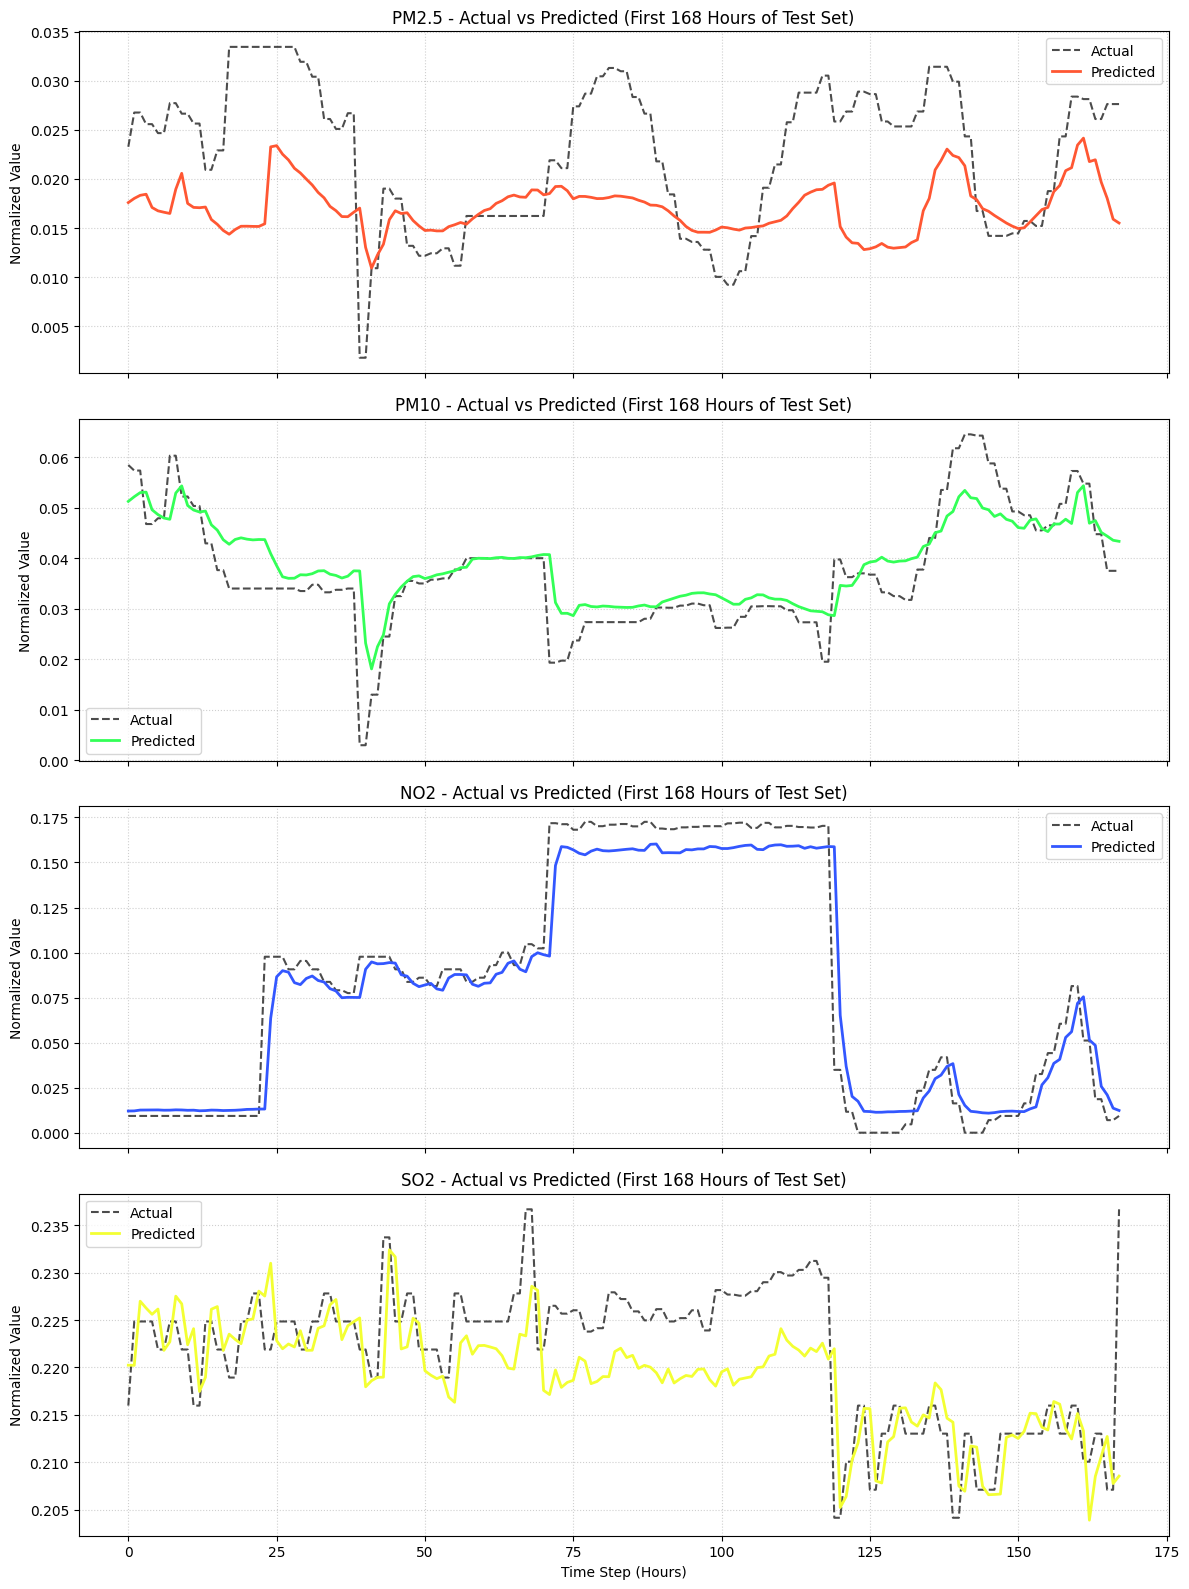

In [7]:
print("Generating prediction plot...")
# Plot first 168 hours (1 week) of test results
plot_hours = min(168, len(y_test))

fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)
colors = ['#FF5733', '#33FF57', '#3357FF', '#F3FF33']

for i, col in enumerate(target_cols):
    ax = axes[i]
    ax.plot(y_test[:plot_hours, i], label='Actual', color='black', alpha=0.7, linestyle='--')
    ax.plot(predictions[:plot_hours, i], label='Predicted', color=colors[i], linewidth=2)
    ax.set_title(f"{col} - Actual vs Predicted (First {plot_hours} Hours of Test Set)")
    ax.set_ylabel("Normalized Value")
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()

plt.xlabel("Time Step (Hours)")
plt.tight_layout()
plot_filename = os.path.join(script_dir, 'lstm_evaluation.png')
plt.savefig(plot_filename, dpi=300)
plt.show()